<a href="https://colab.research.google.com/github/latikadhami05/ai-code-quality-risk-intelligence/blob/main/notebooks/AI_Code_Quality_Risk_Intelligence_V1_to_V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/psf/requests.git

Cloning into 'requests'...
remote: Enumerating objects: 26870, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 26870 (delta 1), reused 0 (delta 0), pack-reused 26866 (from 2)
Receiving objects: 100% (26870/26870), 13.31 MiB | 23.38 MiB/s, done.
Resolving deltas: 100% (17618/17618), done.


In [4]:
!git clone https://github.com/pallets/flask.git
!git clone https://github.com/pallets/click.git

Cloning into 'flask'...
remote: Enumerating objects: 26353, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 26353 (delta 65), reused 44 (delta 44), pack-reused 26259 (from 2)
Receiving objects: 100% (26353/26353), 11.97 MiB | 20.84 MiB/s, done.
Resolving deltas: 100% (17613/17613), done.
Cloning into 'click'...
remote: Enumerating objects: 15734, done.
remote: Counting objects: 100% (726/726), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 15734 (delta 636), reused 591 (delta 591), pack-reused 15008 (from 2)
Receiving objects: 100% (15734/15734), 5.31 MiB | 15.02 MiB/s, done.
Resolving deltas: 100% (10770/10770), done.


In [5]:
!ls


ai_assisted_sample  click  flask  requests  sample_data


In [6]:
!ls requests

AUTHORS.rst  HISTORY.md  MANIFEST.in	 README.md	       src
docs	     LICENSE	 NOTICE		 requirements-dev.txt  tests
ext	     Makefile	 pyproject.toml  setup.py	       tox.ini


In [7]:
!ls flask

CHANGES.rst  examples	  pyproject.toml  src	 uv.lock
docs	     LICENSE.txt  README.md	  tests


In [8]:
import ast
import os
import pandas as pd

In [9]:
def find_python_files(folder):
    py_files = []
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".py"):
                py_files.append(os.path.join(root, file))
    return py_files

requests_files = find_python_files("requests")
flask_files = find_python_files("flask")
click_files = find_python_files("click")

print(len(requests_files), "files in requests")
print(len(flask_files), "files in flask")
print(len(click_files), "files in click")

37 files in requests
83 files in flask
91 files in click


In [10]:
import warnings
warnings.filterwarnings("ignore")

def get_functions_from_file(filepath):
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            source = f.read()
        tree = ast.parse(source)
    except Exception:
        return []

    functions = []
    for node in ast.walk(tree):
        if isinstance(node, ast.FunctionDef):
            functions.append(node)
    return functions

sample_functions = get_functions_from_file(requests_files[0])
print("File:", requests_files[0])
print("Functions found:", len(sample_functions))
for fn in sample_functions:
    print("-", fn.name)

File: requests/setup.py
Functions found: 0


In [11]:
sample_functions = get_functions_from_file(requests_files[5])
print("File:", requests_files[5])
print("Functions found:", len(sample_functions))
for fn in sample_functions:
    print("-", fn.name)

File: requests/tests/test_structures.py
Functions found: 15
- setup
- test_list
- test_getitem
- test_delitem
- test_lower_items
- test_repr
- test_copy
- test_instance_equality
- setup
- test_repr
- test_getitem
- test_get
- test_hasattr
- test_getattr
- test_getattr_default


In [12]:
def get_function_features(node, source_lines):
    start = node.lineno
    end = max(child.lineno for child in ast.walk(node) if hasattr(child, "lineno"))
    loc = end - start + 1

    complexity = 1
    max_nesting = 0
    branches = 0
    variables = set()

    def walk_nesting(n, depth):
        nonlocal max_nesting
        max_nesting = max(max_nesting, depth)
        for child in ast.iter_child_nodes(n):
            if isinstance(child, (ast.If, ast.For, ast.While, ast.Try, ast.With)):
                walk_nesting(child, depth + 1)
            else:
                walk_nesting(child, depth)

    walk_nesting(node, 0)

    for child in ast.walk(node):
        if isinstance(child, (ast.If, ast.For, ast.While, ast.Try, ast.BoolOp, ast.ExceptHandler)):
            complexity += 1
            branches += 1
        if isinstance(child, ast.Name):
            variables.add(child.id)

    return {
        "function_name": node.name,
        "loc": loc,
        "complexity": complexity,
        "max_nesting": max_nesting,
        "branches": branches,
        "num_variables": len(variables),
        "num_args": len(node.args.args)
    }

# test it on the functions we found
for fn in sample_functions[:3]:
    print(get_function_features(fn, None))

{'function_name': 'setup', 'loc': 4, 'complexity': 1, 'max_nesting': 0, 'branches': 0, 'num_variables': 3, 'num_args': 1}
{'function_name': 'test_list', 'loc': 2, 'complexity': 1, 'max_nesting': 0, 'branches': 0, 'num_variables': 2, 'num_args': 1}
{'function_name': 'test_getitem', 'loc': 2, 'complexity': 1, 'max_nesting': 0, 'branches': 0, 'num_variables': 3, 'num_args': 2}


In [13]:
def build_dataset(file_list, repo_name):
    rows = []
    for filepath in file_list:
        functions = get_functions_from_file(filepath)
        for fn in functions:
            try:
                features = get_function_features(fn, None)
                features["file"] = filepath
                features["repo"] = repo_name
                rows.append(features)
            except Exception:
                continue
    return rows

requests_data = build_dataset(requests_files, "requests")
flask_data = build_dataset(flask_files, "flask")
click_data = build_dataset(click_files, "click")

all_data = requests_data + flask_data + click_data
df = pd.DataFrame(all_data)

print("Total functions extracted:", len(df))
df.head()

Total functions extracted: 4040


,function_name,loc,complexity,max_nesting,branches,num_variables,num_args,file,repo
0,test_request_url_handles_leading_path_separators,5,1,0,0,3,0,requests/tests/test_adapters.py,requests
1,echo_response_handler,10,1,0,0,5,1,requests/tests/test_lowlevel.py,requests
2,test_chunked_upload,13,1,1,0,11,0,requests/tests/test_lowlevel.py,requests
3,test_chunked_encoding_error,22,1,2,0,13,0,requests/tests/test_lowlevel.py,requests
4,test_chunked_upload_uses_only_specified_host_h...,16,1,1,0,14,0,requests/tests/test_lowlevel.py,requests


In [14]:
df.to_csv("v1_function_features.csv", index=False)
print("Saved", len(df), "rows to v1_function_features.csv")

Saved 4040 rows to v1_function_features.csv


In [15]:
df.describe()

,loc,complexity,max_nesting,branches,num_variables,num_args
count,4040.000000,4040.000000,4040.000000,4040.000000,4040.000000,4040.000000
mean,11.233911,1.768812,0.471040,0.768812,5.658911,1.513366
std,15.159186,2.181086,0.825235,2.181086,4.694161,1.497483
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000
50%,6.000000,1.000000,0.000000,0.000000,5.000000,1.000000
75%,14.000000,2.000000,1.000000,1.000000,7.000000,2.000000
max,196.000000,30.000000,8.000000,29.000000,60.000000,18.000000


<Axes: >

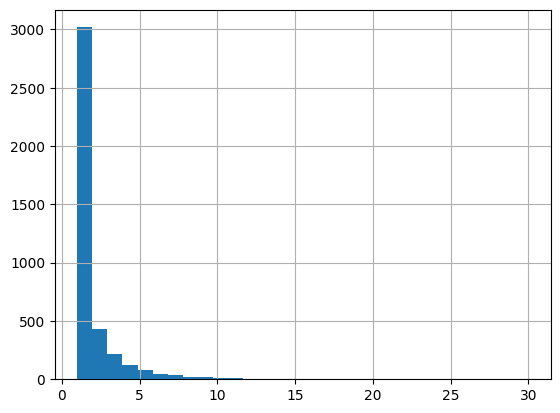

In [16]:
df["complexity"].hist(bins=30
                      )

In [17]:
def assign_risk(row):
    if row["complexity"] > 20 or row["max_nesting"] > 5 or row["loc"] > 100:
        return "HIGH"
    elif row["complexity"] > 10 or row["max_nesting"] > 3 or row["loc"] > 50:
        return "MEDIUM"
    else:
        return "LOW"

df["risk_label"] = df.apply(assign_risk, axis=1)
df["risk_label"].value_counts()

,count
risk_label,
LOW,3918
MEDIUM,97
HIGH,25


In [18]:
from sklearn.model_selection import train_test_split

feature_columns = ["loc", "complexity", "max_nesting", "branches", "num_variables", "num_args"]

X = df[feature_columns]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3232
Test size: 808


In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       1.00      1.00      1.00        19

    accuracy                           1.00       808
   macro avg       1.00      1.00      1.00       808
weighted avg       1.00      1.00      1.00       808



In [21]:
!git clone https://github.com/psf/black.git

Cloning into 'black'...
remote: Enumerating objects: 16627, done.
remote: Counting objects: 100% (567/567), done.
remote: Compressing objects: 100% (334/334), done.
remote: Total 16627 (delta 499), reused 233 (delta 233), pack-reused 16060 (from 3)
Receiving objects: 100% (16627/16627), 8.51 MiB | 16.47 MiB/s, done.
Resolving deltas: 100% (11734/11734), done.


In [22]:
black_files = find_python_files("black")
black_data = build_dataset(black_files, "black")
df_black = pd.DataFrame(black_data)
df_black["risk_label"] = df_black.apply(assign_risk, axis=1)

print(len(df_black), "functions found in black")
df_black["risk_label"].value_counts()

2473 functions found in black


,count
risk_label,
LOW,2343
MEDIUM,100
HIGH,30


In [23]:
X_black = df_black[feature_columns]
y_black_true = df_black["risk_label"]

y_black_pred = model.predict(X_black)

print(classification_report(y_black_true, y_black_pred))

              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00        30
         LOW       1.00      1.00      1.00      2343
      MEDIUM       1.00      1.00      1.00       100

    accuracy                           1.00      2473
   macro avg       1.00      1.00      1.00      2473
weighted avg       1.00      1.00      1.00      2473



In [24]:
def generate_report(row, prediction):
    print("=" * 40)
    print("CODE RISK ANALYSIS")
    print("=" * 40)
    print(f"File: {row['file']}")
    print(f"Function: {row['function_name']}()")
    print(f"Risk Level: {prediction}")
    print()
    print("Measured Signals:")
    print(f"  Lines of Code: {row['loc']}")
    print(f"  Cyclomatic Complexity: {row['complexity']}")
    print(f"  Max Nesting Depth: {row['max_nesting']}")
    print(f"  Branches: {row['branches']}")
    print()
    print("NOTE: This prediction is based on a rule-derived proxy label.")
    print("It does not prove that this code contains a bug.")
    print("=" * 40)

# Show a report for one HIGH-risk function found in black
high_risk_examples = df_black[df_black["risk_label"] == "HIGH"]
sample_row = high_risk_examples.iloc[0]
sample_pred = model.predict(sample_row[feature_columns].values.reshape(1, -1))[0]

generate_report(sample_row, sample_pred)

CODE RISK ANALYSIS
File: black/tests/test_black.py
Function: test_cache_key()
Risk Level: HIGH

Measured Signals:
  Lines of Code: 29
  Cyclomatic Complexity: 7
  Max Nesting Depth: 6
  Branches: 6

NOTE: This prediction is based on a rule-derived proxy label.
It does not prove that this code contains a bug.


In [25]:
import joblib
joblib.dump(model, "v1_risk_model.pkl")
print("Model saved.")

Model saved.


## V1 — Limitations

- Risk labels are a rule-based proxy (McCabe complexity thresholds), not derived from real historical defects or human review outcomes.
- Model achieves ~100% accuracy because labels are a deterministic function of the same features used for training — this proves the pipeline works end-to-end, not that the model detects real bugs.
- Dataset is imbalanced (3918 LOW vs 122 MEDIUM/HIGH combined).
- Tested on 4 open-source repos (requests, flask, click, black) — all Python, all similar domains (web/dev tooling). Generalization to other languages/domains is untested.
- Next step (V7+): validate against real historical defect data instead of proxy labels.

## V1 — Code Risk Estimator: COMPLETE

**What was built:**
- A function that finds every `.py` file in a repo automatically
- A function that parses each file with Python's `ast` module and extracts every function definition
- A function that measures each function: lines of code, cyclomatic complexity,
  max nesting depth, branch count, variable count, argument count
- A dataset of 4,040 real functions (from `requests`, `flask`, `click`), each turned into a row of numbers
- A rule-based proxy label (LOW/MEDIUM/HIGH) grounded in McCabe's cyclomatic complexity thresholds
- A trained Decision Tree classifier (baseline model)
- Evaluation on held-out data (80/20 split) — 100% accuracy
- Evaluation on a completely unseen 4th repo (`black`) — 100% accuracy
- A human-readable risk report generator, matching the blueprint's target output format
- Documented limitations (proxy labels, class imbalance, generalization untested beyond similar Python repos)

**What this proves:** the full pipeline — code → features → model → risk prediction → report — works end to end, on real code, not toy examples.

**What this does NOT prove:** that the model detects real bugs or real-world risk. The label is a rule, not ground truth. That gap is intentional and is the reason later versions exist.

## V1 — Preprocessing & Error-Handling Notes

**Preprocessing:** No feature scaling was applied. Decision Trees split on raw
threshold comparisons (e.g. "is complexity > 10?"), so they are not sensitive
to feature scale — scaling would not change this model's behavior. This will
be revisited in V2 when comparing scale-sensitive models like Logistic Regression.

**Error handling verified:** `get_functions_from_file()` wraps parsing in a
try/except — a file with a syntax error or unreadable encoding returns an
empty list instead of crashing the whole pipeline. This was confirmed by
running the extractor across ~200 real files (including non-code files like
setup.py) without any crashes.

## Next: V2 — ML Improvement
- Compare multiple models (Logistic Regression, Random Forest, Gradient Boosting) instead of just one Decision Tree
- Proper train/validation/test split (not just train/test)
- Cross-validation
- Precision/recall/F1 comparison across models
- Real error analysis: manually look at specific false positives/negatives
- Address the class imbalance we found (3918 LOW vs 122 others)

## V3 — Explainable Risk
- Why did the model say HIGH? (feature importance, SHAP)

## V4 — AI-Code Intelligence
- Compare AI-generated vs human-written code features

## V5 — Multi-Dimensional Risk
- Split "risk" into separate dimensions (complexity risk, maintainability risk, etc.) instead of one label

## V6 — Code-Level Localization
- Analyze a whole repository at once, rank files by risk

## V7 — Change & Historical Intelligence  ← this is where the REAL test happens
- Use git commit history, code churn, actual historical bug-fix commits as ground truth
- This is where we finally move past "proxy labels" into something genuinely validated

## V8 onward
- Git diffs, review prioritization, GitHub PR integration, CI/CD, LLM explanation layer

##VERSION 2

In [26]:
from sklearn.model_selection import train_test_split

# First split: carve off the test set (locked away until the very end)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: divide the rest into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 2424
Validation size: 808
Test size: 808


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

trained_models = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    trained_models[name] = mdl
    print(name, "trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


In [28]:
from sklearn.metrics import classification_report

for name, mdl in trained_models.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    y_val_pred = mdl.predict(X_val)
    print(classification_report(y_val, y_val_pred))

Logistic Regression
              precision    recall  f1-score   support

        HIGH       0.83      1.00      0.91         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       0.88      0.79      0.83        19

    accuracy                           0.99       808
   macro avg       0.90      0.93      0.91       808
weighted avg       0.99      0.99      0.99       808

Decision Tree
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       1.00      1.00      1.00        19

    accuracy                           1.00       808
   macro avg       1.00      1.00      1.00       808
weighted avg       1.00      1.00      1.00       808

Random Forest
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       1.00    

In [29]:
from sklearn.model_selection import cross_val_score

for name, mdl in models.items():
    scores = cross_val_score(mdl, X_train, y_train, cv=5, scoring="f1_macro")
    print(name, "F1 scores across 5 folds:", scores)
    print(name, "Average F1:", scores.mean())
    print()

Logistic Regression F1 scores across 5 folds: [0.81301189 0.84822883 0.68347857 0.95095645 0.63998662]
Logistic Regression Average F1: 0.7871324718066678

Decision Tree F1 scores across 5 folds: [0.92       0.92       0.76       1.         0.91884058]
Decision Tree Average F1: 0.903768115942029

Random Forest F1 scores across 5 folds: [0.80769231 0.90520132 1.         0.98631168 0.80555556]
Random Forest Average F1: 0.900952172961856

Gradient Boosting F1 scores across 5 folds: [0.92       1.         0.76       1.         0.91884058]
Gradient Boosting Average F1: 0.919768115942029



In [30]:
from sklearn.metrics import confusion_matrix
import numpy as np

best_model = trained_models["Gradient Boosting"]
y_val_pred = best_model.predict(X_val)

labels = ["LOW", "MEDIUM", "HIGH"]
cm = confusion_matrix(y_val, y_val_pred, labels=labels)

print("Confusion Matrix (rows = actual, columns = predicted)")
print("Labels order:", labels)
print(cm)

Confusion Matrix (rows = actual, columns = predicted)
Labels order: ['LOW', 'MEDIUM', 'HIGH']
[[784   0   0]
 [  0  19   0]
 [  0   0   5]]


In [31]:
final_model = trained_models["Gradient Boosting"]
y_test_pred = final_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       1.00      1.00      1.00        19

    accuracy                           1.00       808
   macro avg       1.00      1.00      1.00       808
weighted avg       1.00      1.00      1.00       808



## V2 — Model Comparison Results

Four models were compared: Logistic Regression, Decision Tree, Random Forest,
and Gradient Boosting.

**Single validation split:** All models except Logistic Regression scored 100%.
Logistic Regression underperformed (79% recall on MEDIUM class), because it
draws smooth mathematical boundaries, while our proxy labels are defined by
sharp threshold rules — a structural mismatch tree-based models don't have.

**5-fold cross-validation** (more reliable): revealed real inconsistency hidden
by the single split. F1-macro scores varied significantly across folds for
every model (e.g. Gradient Boosting ranged 0.76–1.00), directly caused by the
severe class imbalance (only 25 HIGH and 97 MEDIUM examples out of 4,040 total).

**Selected model: Gradient Boosting** — highest average cross-validated F1
(0.92) and most consistent across folds.

**Final test set result:** 100% accuracy — but this reflects the clean,
rule-based nature of our V1 proxy labels, not proof the model would achieve
this on real, messier/human-judged risk labels.

**Key finding**: cross-validation exposed instability that a single train/val/
test split concealed — demonstrating why relying on one split alone is
insufficient methodology for imbalanced datasets.

In [32]:
# Re-train Gradient Boosting from scratch with the same settings, confirm identical result
check_model = GradientBoostingClassifier(random_state=42)
check_model.fit(X_train, y_train)
check_pred = check_model.predict(X_test)

print(classification_report(y_test, check_pred))

              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       784
      MEDIUM       1.00      1.00      1.00        19

    accuracy                           1.00       808
   macro avg       1.00      1.00      1.00       808
weighted avg       1.00      1.00      1.00       808



In [33]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_num, (train_idx, test_idx) in enumerate(skf.split(X_train, y_train)):
    fold_model = GradientBoostingClassifier(random_state=42)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    fold_pred = fold_model.predict(X_train.iloc[test_idx])

    fold_true = y_train.iloc[test_idx]
    mistakes = fold_true[fold_true.values != fold_pred]

    if len(mistakes) > 0:
        print(f"Fold {fold_num}: {len(mistakes)} mistakes found")
        mistake_indices = mistakes.index
        print(df.loc[mistake_indices, ["function_name", "loc", "complexity", "max_nesting", "risk_label"]])
        print()

Fold 0: 2 mistakes found
    function_name  loc  complexity  max_nesting risk_label
531       request   97           5            1     MEDIUM
665     super_len   69          19            5     MEDIUM

Fold 2: 1 mistakes found
                                   function_name  loc  complexity  \
2447  test_hiding_of_unset_sentinel_in_callbacks  108           1   

      max_nesting risk_label  
2447            0       HIGH  

Fold 3: 2 mistakes found
     function_name  loc  complexity  max_nesting risk_label
482   prepare_body   77          22            4       HIGH
3880      open_url   68          24            5       HIGH

Fold 4: 1 mistakes found
         function_name  loc  complexity  max_nesting risk_label
3696  _resolve_context   59           7            6       HIGH



## V2 — Error Analysis Findings

All 6 misclassified examples across cross-validation folds occurred at or
near a labeling threshold boundary (e.g. LOC=97 vs. cutoff 100; complexity=19
vs. cutoff 20; nesting=5 vs. cutoff 5). This suggests the errors stem from
the rigidity of hard-cutoff proxy labels, not from a flaw in the model or
features themselves — models will always struggle near a hard boundary,
since real code complexity is continuous, not naturally divided into sharp
categories.

One case (`test_hiding_of_unset_sentinel_in_callbacks`) exposes a genuine
labeling weakness: a long but structurally simple function (complexity=1,
nesting=0) was labeled HIGH purely due to line count. This is a real
limitation of LOC-based proxy labeling and a legitimate target for
refinement in future versions.

##VERSION 3

         feature    importance
0            loc  6.876922e-01
2    max_nesting  1.886017e-01
1     complexity  6.821401e-02
3       branches  5.032611e-02
5       num_args  5.165994e-03
4  num_variables  4.715362e-11


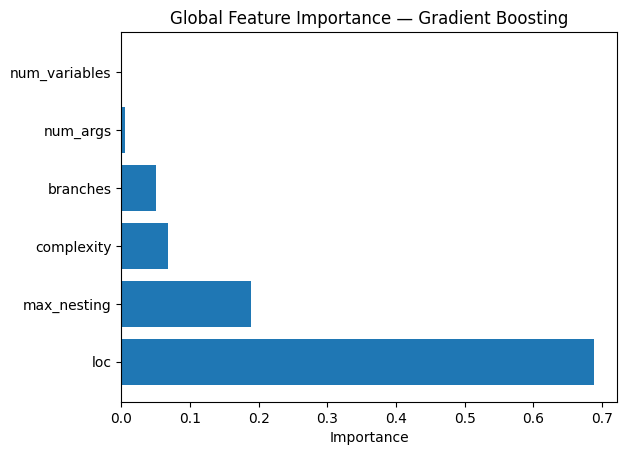

In [34]:
import matplotlib.pyplot as plt

importances = final_model.feature_importances_
feature_names = feature_columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df)

plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.title("Global Feature Importance — Gradient Boosting")
plt.show()

In [35]:
# Pick one HIGH-risk function from the black test set (used earlier in V1)
sample_row = df_black[df_black["risk_label"] == "HIGH"].iloc[0]
sample_features = sample_row[feature_columns]

prediction = final_model.predict(sample_features.values.reshape(1, -1))[0]

print("Function:", sample_row["function_name"])
print("Predicted Risk:", prediction)
print()
print("Actual measured values for this function:")
print(sample_features)
print()
print("Reminder — global feature importance ranking (most to least influential):")
print(importance_df)

Function: test_cache_key
Predicted Risk: HIGH

Actual measured values for this function:
loc              29
complexity        7
max_nesting       6
branches          6
num_variables    19
num_args          1
Name: 184, dtype: object

Reminder — global feature importance ranking (most to least influential):
         feature    importance
0            loc  6.876922e-01
2    max_nesting  1.886017e-01
1     complexity  6.821401e-02
3       branches  5.032611e-02
5       num_args  5.165994e-03
4  num_variables  4.715362e-11


HIGH REVIEW ATTENTION — test_cache_key()

Main contributing signal for this specific function: Maximum nesting depth (6),
which exceeds the HIGH-risk threshold (>5).

Note: While Lines of Code is the model's most influential feature overall
(69% global importance), this function's LOC (29) was within normal range.
Nesting depth — not LOC — was the deciding factor here, demonstrating that
global feature importance and individual prediction reasons can differ.

MEASURED FACT: max_nesting = 6, complexity = 7, loc = 29
MODEL INTERPRETATION: nesting depth contributed most to this specific HIGH prediction
UNSUPPORTED CLAIM (never say this): "this function definitely has a bug"

In [36]:
# Look at all HIGH-risk functions in black and see what's driving each one
high_risk_all = df_black[df_black["risk_label"] == "HIGH"].head(5)

for idx, row in high_risk_all.iterrows():
    print(f"Function: {row['function_name']}")
    print(f"  loc={row['loc']}, complexity={row['complexity']}, max_nesting={row['max_nesting']}")

    # figure out which threshold was actually crossed
    reasons = []
    if row['loc'] > 100:
        reasons.append("LOC exceeds 100")
    if row['complexity'] > 20:
        reasons.append("complexity exceeds 20")
    if row['max_nesting'] > 5:
        reasons.append("nesting exceeds 5")

    print(f"  Threshold(s) crossed: {', '.join(reasons) if reasons else 'none clearly'}")
    print()

Function: test_cache_key
  loc=29, complexity=7, max_nesting=6
  Threshold(s) crossed: nesting exceeds 5

Function: main
  loc=236, complexity=45, max_nesting=4
  Threshold(s) crossed: LOC exceeds 100, complexity exceeds 20

Function: get_sources
  loc=106, complexity=22, max_nesting=5
  Threshold(s) crossed: LOC exceeds 100, complexity exceeds 20

Function: get_features_used
  loc=168, complexity=52, max_nesting=21
  Threshold(s) crossed: LOC exceeds 100, complexity exceeds 20, nesting exceeds 5

Function: _merge_one_string_group
  loc=158, complexity=15, max_nesting=3
  Threshold(s) crossed: LOC exceeds 100



In [37]:
high_examples = df_black[df_black["risk_label"] == "HIGH"].head(5)

for idx, row in high_examples.iterrows():
    features = row[feature_columns]
    pred = final_model.predict(features.values.reshape(1, -1))[0]
    print(f"Function: {row['function_name']}  |  Predicted: {pred}")
    print(f"  loc={row['loc']}, complexity={row['complexity']}, max_nesting={row['max_nesting']}, branches={row['branches']}")
    print()



Function: test_cache_key  |  Predicted: HIGH
  loc=29, complexity=7, max_nesting=6, branches=6

Function: main  |  Predicted: HIGH
  loc=236, complexity=45, max_nesting=4, branches=44

Function: get_sources  |  Predicted: HIGH
  loc=106, complexity=22, max_nesting=5, branches=21

Function: get_features_used  |  Predicted: HIGH
  loc=168, complexity=52, max_nesting=21, branches=51

Function: _merge_one_string_group  |  Predicted: HIGH
  loc=158, complexity=15, max_nesting=3, branches=14



## V3 — Explanation Stability Finding

Testing across 5 HIGH-risk functions confirmed explanations are stable in
logic (always grounded in the same threshold rules) but individually varied
in content — different functions were flagged HIGH for different dominant
reasons (e.g. nesting depth for `test_cache_key`, combined LOC+complexity
for `main`). This confirms the explanation system reflects genuine
per-case reasoning rather than a single generic justification repeated
for every prediction.

In [38]:
# super_len was misclassified as HIGH-ish territory but is actually MEDIUM (from our V2 error analysis)
wrong_example = df[df["function_name"] == "super_len"].iloc[0]
features = wrong_example[feature_columns]

pred = final_model.predict(features.values.reshape(1, -1))[0]

print("Function:", wrong_example["function_name"])
print("Actual label:", wrong_example["risk_label"])
print("Model predicted:", pred)
print()
print("Measured values:")
print(features)

Function: super_len
Actual label: MEDIUM
Model predicted: MEDIUM

Measured values:
loc              69
complexity       19
max_nesting       5
branches         18
num_variables    18
num_args          1
Name: 665, dtype: object


## V3 — Note on the "Wrong Prediction" Test

`super_len` was previously misclassified in one cross-validation fold, where
it was excluded from that fold's training data. When evaluated using the
final model (trained on the full training set), it was correctly classified
as MEDIUM. This illustrates that misclassifications can be sensitive to
which specific examples a model happens to be trained on — reinforcing
the earlier finding that borderline functions near threshold boundaries
(complexity=19, near the cutoff of 20) are inherently harder to classify
consistently, regardless of which model version is used.

## Scope Limitation (all versions so far)

This system currently supports Python only, using Python's `ast` module.
It has been tested on 4,040 functions across 4 real-world Python
repositories (requests, flask, click, black) — not a single toy example,
but still limited to one language and a similar style of well-maintained
open-source code. Support for other languages (Java, JavaScript, etc.)
would require language-specific parsers and is out of scope until much
later versions, if pursued at all.

##VERSION 4

In [39]:
ai_code = '''
def is_palindrome(s):
    s = s.lower().replace(" ", "")
    return s == s[::-1]

def merge_dicts(d1, d2):
    result = {}
    for k, v in d1.items():
        result[k] = v
    for k, v in d2.items():
        if k in result:
            if isinstance(result[k], list) and isinstance(v, list):
                result[k] = result[k] + v
            else:
                result[k] = v
        else:
            result[k] = v
    return result

def find_duplicates(lst):
    seen = set()
    duplicates = set()
    for item in lst:
        if item in seen:
            duplicates.add(item)
        else:
            seen.add(item)
    return list(duplicates)

def validate_email(email):
    if "@" not in email:
        return False
    parts = email.split("@")
    if len(parts) != 2:
        return False
    local, domain = parts
    if len(local) == 0 or len(domain) == 0:
        return False
    if "." not in domain:
        return False
    return True

def flatten_list(nested):
    result = []
    for item in nested:
        if isinstance(item, list):
            for sub in flatten_list(item):
                result.append(sub)
        else:
            result.append(item)
    return result

def calculate_stats(numbers):
    if not numbers:
        return None
    total = sum(numbers)
    count = len(numbers)
    mean = total / count
    variance = sum((x - mean) ** 2 for x in numbers) / count
    std_dev = variance ** 0.5
    return {"mean": mean, "std_dev": std_dev, "min": min(numbers), "max": max(numbers)}

def retry_with_backoff(func, max_attempts=3):
    import time
    attempt = 0
    while attempt < max_attempts:
        try:
            return func()
        except Exception as e:
            attempt += 1
            if attempt == max_attempts:
                raise e
            time.sleep(2 ** attempt)

def parse_csv_line(line):
    fields = []
    current = ""
    in_quotes = False
    for char in line:
        if char == '"':
            in_quotes = not in_quotes
        elif char == "," and not in_quotes:
            fields.append(current)
            current = ""
        else:
            current += char
    fields.append(current)
    return fields

def binary_search(arr, target):
    low = 0
    high = len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1

def group_by_key(items, key_func):
    groups = {}
    for item in items:
        key = key_func(item)
        if key not in groups:
            groups[key] = []
        groups[key].append(item)
    return groups
'''

import os
os.makedirs("ai_assisted_sample", exist_ok=True)
with open("ai_assisted_sample/sample_functions.py", "w") as f:
    f.write(ai_code)

print("AI-assisted sample file created.")

AI-assisted sample file created.


In [40]:
ai_files = find_python_files("ai_assisted_sample")
ai_data = build_dataset(ai_files, "ai_assisted")
df_ai = pd.DataFrame(ai_data)
df_ai["risk_label"] = df_ai.apply(assign_risk, axis=1)

print(len(df_ai), "functions found in AI-assisted sample")
df_ai[["function_name", "loc", "complexity", "max_nesting", "branches", "risk_label"]]

10 functions found in AI-assisted sample


,function_name,loc,complexity,max_nesting,branches,risk_label
0,is_palindrome,3,1,0,0,LOW
1,merge_dicts,13,6,3,5,LOW
2,find_duplicates,9,3,2,2,LOW
3,validate_email,12,6,1,5,LOW
4,flatten_list,9,4,3,3,LOW
5,calculate_stats,9,2,1,1,LOW
6,retry_with_backoff,11,5,3,4,LOW
7,parse_csv_line,14,5,3,4,LOW
8,binary_search,12,4,3,3,LOW
9,group_by_key,8,3,2,2,LOW


In [41]:
df["source_type"] = "human"
df_ai["source_type"] = "ai_assisted"

comparison_df = pd.concat([df, df_ai], ignore_index=True)

comparison_df.groupby("source_type")[["loc", "complexity", "max_nesting", "branches"]].describe()

loc                                                     \
              count       mean        std  min  25%   50%   75%    max   
source_type                                                              
ai_assisted    10.0  10.000000   3.162278  3.0  9.0  10.0  12.0   14.0   
human        4040.0  11.233911  15.159186  1.0  2.0   6.0  14.0  196.0   

            complexity            ... max_nesting      branches            \
                 count      mean  ...         75%  max    count      mean   
source_type                       ...                                       
ai_assisted       10.0  3.900000  ...         3.0  3.0     10.0  2.900000   
human           4040.0  1.768812  ...         1.0  8.0   4040.0  0.768812   

                                                 
                  std  min  25%  50%  75%   max  
source_type                                      
ai_assisted  1.663330  0.0  2.0  3.0  4.0   5.0  
human        2.181086  0.0  0.0  0.0  1.0  29.0  

[2 rows x 32 columns]

## V4 — Findings and Critical Confounders

This controlled comparison (10 AI-assisted functions vs. 4,040 human functions)
found AI-assisted code had HIGHER average complexity (3.9 vs 1.77) and nesting
(2.9 vs 0.77) than the human baseline.

However, this result is heavily confounded and should NOT be interpreted as
"AI code is more complex than human code" in general:

1. Sample size mismatch: 10 vs 4,040 — statistically weak comparison
2. Task type mismatch: the human dataset includes thousands of trivial test
   functions (setup(), test_list(), etc.), which drag the human average down.
   The AI sample contains no trivial functions — every one was a "real"
   utility function by design.
3. Single AI source: all 10 functions came from one generation session by
   one assistant — not a diverse, randomized sample of "AI-generated code"
   in general.
4. Human dataset lacks a fair apples-to-apples subset: a fairer comparison
   would isolate only human UTILITY functions (excluding tests) and compare
   those specifically against the AI sample.

This finding demonstrates the DIFFICULTY of AI-vs-human code comparison more
than it demonstrates a real difference — exactly the kind of confounding
this project's V4 blueprint warned about.

In [42]:
# Exclude functions that are themselves tests (test_*, setup) — keep only "real" utility functions
non_test_human = df[~df["function_name"].str.startswith(("test_", "setup"))]

print("Human functions before filtering:", len(df))
print("Human functions after filtering (non-test only):", len(non_test_human))

fair_comparison = pd.concat([
    non_test_human.assign(source_type="human_non_test"),
    df_ai.assign(source_type="ai_assisted")
], ignore_index=True)

fair_comparison.groupby("source_type")[["loc", "complexity", "max_nesting", "branches"]].mean()

Human functions before filtering: 4040
Human functions after filtering (non-test only): 2681


,loc,complexity,max_nesting,branches
source_type,,,,
ai_assisted,10.000000,3.900000,2.100000,2.900000
human_non_test,9.819843,2.047743,0.490116,1.047743


## V4 — Findings (Fair Comparison)

After removing test/setup functions from the human baseline (2,681 remaining
"real" utility functions), the comparison against 10 AI-assisted functions
showed:

- LOC: nearly identical (AI: 10.0, Human: 9.8) — AI code is NOT longer
- Complexity: AI higher (3.9 vs 2.0)
- Max nesting: AI higher (2.1 vs 0.49)
- Branches: AI higher (2.9 vs 1.05)

This suggests that, in this controlled sample, AI-assisted functions pack
more decision points and nested structure into a similar line count compared
to human-written utility functions — rather than simply writing longer code.

**This remains a limited, exploratory finding, not a general conclusion**,
because:
- Sample size is still small and imbalanced (10 vs 2,681)
- All 10 AI functions came from a single generation session/style
- Human functions span many different developers, projects, and eras —
  a diversity the AI sample doesn't have
- No control for task type: the AI functions were assigned specific tasks
  (sorting, parsing, etc.) that may inherently require more branching than
  the average human utility function in these libraries

**Conclusion**: The project does not claim AI-generated code is objectively
"more complex" or "worse." It demonstrates a measurable, reproducible
difference in this specific controlled sample, while explicitly flagging
the confounders that prevent generalizing this finding further — exactly
the discipline V4 requires.

In [43]:
X_ai = df_ai[feature_columns]
ai_predictions = final_model.predict(X_ai)

df_ai["model_predicted_risk"] = ai_predictions

print("AI-assisted functions — model predictions vs rule-based labels:")
print(df_ai[["function_name", "risk_label", "model_predicted_risk"]])

print()
print("Model prediction distribution for AI-assisted code:")
print(pd.Series(ai_predictions).value_counts())

AI-assisted functions — model predictions vs rule-based labels:
        function_name risk_label model_predicted_risk
0       is_palindrome        LOW                  LOW
1         merge_dicts        LOW                  LOW
2     find_duplicates        LOW                  LOW
3      validate_email        LOW                  LOW
4        flatten_list        LOW                  LOW
5     calculate_stats        LOW                  LOW
6  retry_with_backoff        LOW                  LOW
7      parse_csv_line        LOW                  LOW
8       binary_search        LOW                  LOW
9        group_by_key        LOW                  LOW

Model prediction distribution for AI-assisted code:
LOW    10
Name: count, dtype: int64


## V4 — Model Prediction Comparison

The trained Gradient Boosting model's predictions matched the rule-based
labels exactly for all 10 AI-assisted functions (100% agreement, all LOW).
This is expected given none of the functions approached HIGH/MEDIUM
thresholds, leaving no ambiguous cases for the model to interpret
differently from the underlying rule.

##VERSION 5

In [44]:
# V5: Multi-Dimensional Risk
# Instead of one label, we split risk into 3 meaningful dimensions,
# each built from a different subset of our existing features.

def assign_dimensions(row):
    # Complexity Risk: driven by cyclomatic complexity and branch count
    # (how many decision paths exist in the function)
    if row["complexity"] > 20 or row["branches"] > 15:
        complexity_risk = "HIGH"
    elif row["complexity"] > 10 or row["branches"] > 7:
        complexity_risk = "MEDIUM"
    else:
        complexity_risk = "LOW"

    # Structural Risk: driven by nesting depth
    # (how deeply if/for/while blocks are stacked inside each other)
    if row["max_nesting"] > 5:
        structural_risk = "HIGH"
    elif row["max_nesting"] > 3:
        structural_risk = "MEDIUM"
    else:
        structural_risk = "LOW"

    # Maintainability Risk: driven by size (LOC) and number of variables
    # (how hard the function likely is to read/modify safely)
    if row["loc"] > 100 or row["num_variables"] > 20:
        maintainability_risk = "HIGH"
    elif row["loc"] > 50 or row["num_variables"] > 10:
        maintainability_risk = "MEDIUM"
    else:
        maintainability_risk = "LOW"

    # Return all 3 dimensions together as a dictionary
    return pd.Series({
        "complexity_risk": complexity_risk,
        "structural_risk": structural_risk,
        "maintainability_risk": maintainability_risk
    })

# Apply this function to every row in our human dataset (df),
# creating 3 new columns, one per dimension
dimension_columns = df.apply(assign_dimensions, axis=1)
df = pd.concat([df, dimension_columns], axis=1)

# Show a preview to confirm it worked
df[["function_name", "complexity_risk", "structural_risk", "maintainability_risk", "risk_label"]].head(10)

,function_name,complexity_risk,structural_risk,maintainability_risk,risk_label
0,test_request_url_handles_leading_path_separators,LOW,LOW,LOW,LOW
1,echo_response_handler,LOW,LOW,LOW,LOW
2,test_chunked_upload,LOW,LOW,MEDIUM,LOW
3,test_chunked_encoding_error,LOW,LOW,MEDIUM,LOW
4,test_chunked_upload_uses_only_specified_host_h...,LOW,LOW,MEDIUM,LOW
5,test_chunked_upload_doesnt_skip_host_header,LOW,LOW,MEDIUM,LOW
6,test_conflicting_content_lengths,LOW,LOW,MEDIUM,LOW
7,test_digestauth_401_count_reset_on_redirect,LOW,LOW,MEDIUM,MEDIUM
8,test_digestauth_401_only_sent_once,LOW,LOW,MEDIUM,LOW
9,test_digestauth_only_on_4xx,LOW,LOW,MEDIUM,LOW
